# PaSCient: supervised sample-level representations

[PaSCient](https://github.com/genentech/pascient) ([Rauer et al., 2024](https://arxiv.org/abs/2404.14413)) is a supervised deep learning method that learns patient-level representations from single-cell data. It uses a gene-to-cell encoder, attention-based cell-to-patient aggregation, and a patient encoder to produce fixed-size sample embeddings.

This notebook demonstrates how to use PaSCient through `patpy` on the COMBAT dataset.

## Setup

In [1]:
import pandas as pd
import scanpy as sc
import patpy
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [2]:
patpy.__version__

'0.14.0'

## Load and prepare data

We use the COMBAT dataset ([COMBAT Consortium, 2022](https://doi.org/10.1016/j.cell.2022.01.012)), available on [Kaggle](https://www.kaggle.com/datasets/vshitov/combat-covid-19-single-cell).

In [3]:
ADATA_PATH = "/home/icb/vladimir.shitov/projects/vladimir.shitov/2023_05_patient_representation_benchmark/reproducibility/pat_rep_benchmark/data/combat/combat_processed.h5ad"

In [4]:
adata = sc.read_h5ad(ADATA_PATH)
adata

AnnData object with n_obs × n_vars = 783677 × 3000
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC

In [5]:
sample_id_col = "scRNASeq_sample_ID"
cell_type_key = "cell_type"
samples_metadata_cols = ["Source", "Outcome", "Death28", "Institute", "Pool_ID", "binary_condition"]

In [6]:
adata.obs.rename(columns={"Annotation_major_subset": cell_type_key}, inplace=True)

In [7]:
adata = adata[~adata.obs["Source"].isin(["Sepsis", "Flu"])]
adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int)
adata.obs["binary_condition"].value_counts()

/localscratch/vladimir.shitov/ipykernel_2436341/1289119485.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int)


binary_condition
1    524530
0     87204
Name: count, dtype: int64

In [8]:
metadata = adata.obs[samples_metadata_cols + [sample_id_col]].drop_duplicates()
metadata.set_index(sample_id_col, inplace=True)
metadata

,Source,Outcome,Death28,Institute,Pool_ID,binary_condition
scRNASeq_sample_ID,,,,,,
S00109-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexA,1
S00112-Ja003E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexA,1
S00005-Ja005E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexA,1
S00061-Ja003E-PBCa,COVID_SEV,4.0,0,Oxford,gPlexA,1
S00056-Ja003E-PBCa,COVID_SEV,3.0,0,Oxford,gPlexA,1
...,...,...,...,...,...,...
S00076-Ja001E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexK,1
S00072-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexK,1
S00065-Ja003E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexK,1


In [9]:
adata = patpy.pp.filter_small_samples(adata, sample_key=sample_id_col, sample_size_threshold=250)

0 samples removed: 


## Train PaSCient

Initialize PaSCient with the default hyperparameters. We train from scratch on this dataset by passing `train=True` to `prepare_anndata`.

**Important:** PaSCient expects gene expression as input. You can either provide raw counts via the `layer` parameter (with `normalize=True`, the default, which applies log-normalization automatically), or provide already log-normalized data in `adata.X` (with `normalize=False`). Providing the correct expression input is critical for good performance.

In [10]:
pascient = patpy.tl.supervised.PaSCient(
    sample_key=sample_id_col,
    label_keys=["binary_condition"],
    tasks=["classification"],
    layer="X_raw_counts",
    normalize=True,
    n_cells=1500,
    batch_size=16,
    n_epochs=4,
    device="cuda",
)

In [11]:
pascient.prepare_anndata(adata, train=True)

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'gene2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['gene2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2patient_aggregation' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2patient_aggregatio

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 10. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 16. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 11. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

`Trainer.fit` stopped: `max_epochs=4` reached.


## Sample representations

Extract sample-level embeddings and evaluate using the KNN prediction score.

In [12]:
pascient_sample_reps = pascient.get_sample_representations()
pascient_sample_reps

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_502,dim_503,dim_504,dim_505,dim_506,dim_507,dim_508,dim_509,dim_510,dim_511
S00109-Ja001E-PBCa,0.881087,-0.015332,-0.047336,-0.058653,0.478373,-0.006281,-0.066455,0.810141,-0.110680,0.009029,...,-0.153801,0.600624,0.147813,-0.119102,0.000229,0.619477,-0.046709,-0.051285,-0.035070,-0.012824
S00112-Ja003E-PBCa,0.990882,-0.013813,-0.051293,-0.060252,0.529350,-0.012506,-0.072136,0.895822,-0.117719,0.027942,...,-0.174409,0.683192,0.160737,-0.130958,-0.004540,0.623760,-0.047572,-0.055053,-0.035659,-0.001140
S00005-Ja005E-PBCa,0.972803,-0.012629,-0.059363,-0.067471,0.524902,-0.015401,-0.079500,0.885053,-0.114808,0.027688,...,-0.172071,0.668580,0.159640,-0.134134,0.013816,0.595265,-0.049971,-0.046660,-0.030702,0.030427
S00061-Ja003E-PBCa,1.108316,-0.014541,-0.056737,-0.081444,0.624105,-0.020111,-0.079139,1.068016,-0.137718,0.023408,...,-0.198452,0.747298,0.201229,-0.155067,-0.004465,0.727791,-0.062068,-0.062576,-0.042381,-0.006325
S00056-Ja003E-PBCa,1.013072,-0.010412,-0.058116,-0.076305,0.537114,-0.018204,-0.073656,0.927697,-0.121569,0.031819,...,-0.185642,0.703348,0.168900,-0.138590,-0.001699,0.622526,-0.049385,-0.054082,-0.036455,0.014853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,0.906240,-0.012467,-0.053569,-0.054505,0.432835,-0.007024,-0.067679,0.801963,-0.113578,-0.001691,...,-0.153800,0.613327,0.130779,-0.118596,-0.005430,0.567807,-0.049046,-0.043926,-0.028642,0.009355
S00072-Ja001E-PBCa,0.858072,-0.012022,-0.053428,-0.065971,0.410611,-0.009559,-0.061926,0.766771,-0.120860,-0.005676,...,-0.138934,0.577311,0.110755,-0.109372,-0.005815,0.579229,-0.061922,-0.046589,-0.039030,-0.010846
S00065-Ja003E-PBCa,0.995233,-0.009444,-0.061180,-0.071810,0.500640,-0.010662,-0.068464,0.913587,-0.124567,0.016715,...,-0.166232,0.649046,0.137203,-0.136963,-0.004715,0.606029,-0.054840,-0.052968,-0.030530,0.005756
S00048-Ja003E-PBCa,0.973248,-0.009442,-0.057814,-0.065891,0.467158,-0.013163,-0.074500,0.873470,-0.113922,0.009640,...,-0.161096,0.660398,0.146977,-0.131002,0.005415,0.599650,-0.053120,-0.049833,-0.029242,0.007552


In [13]:
pascient_distances = pascient.calculate_distance_matrix()
patpy.tl.evaluate_representation(
    pascient_distances,
    target=metadata.loc[pascient.samples, "binary_condition"],
    task="classification"
)

{'score': 0.8979797979797981,
 'metric': 'f1_macro_calibrated',
 'n_unique': 2,
 'n_observations': 101,
 'method': 'knn'}

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


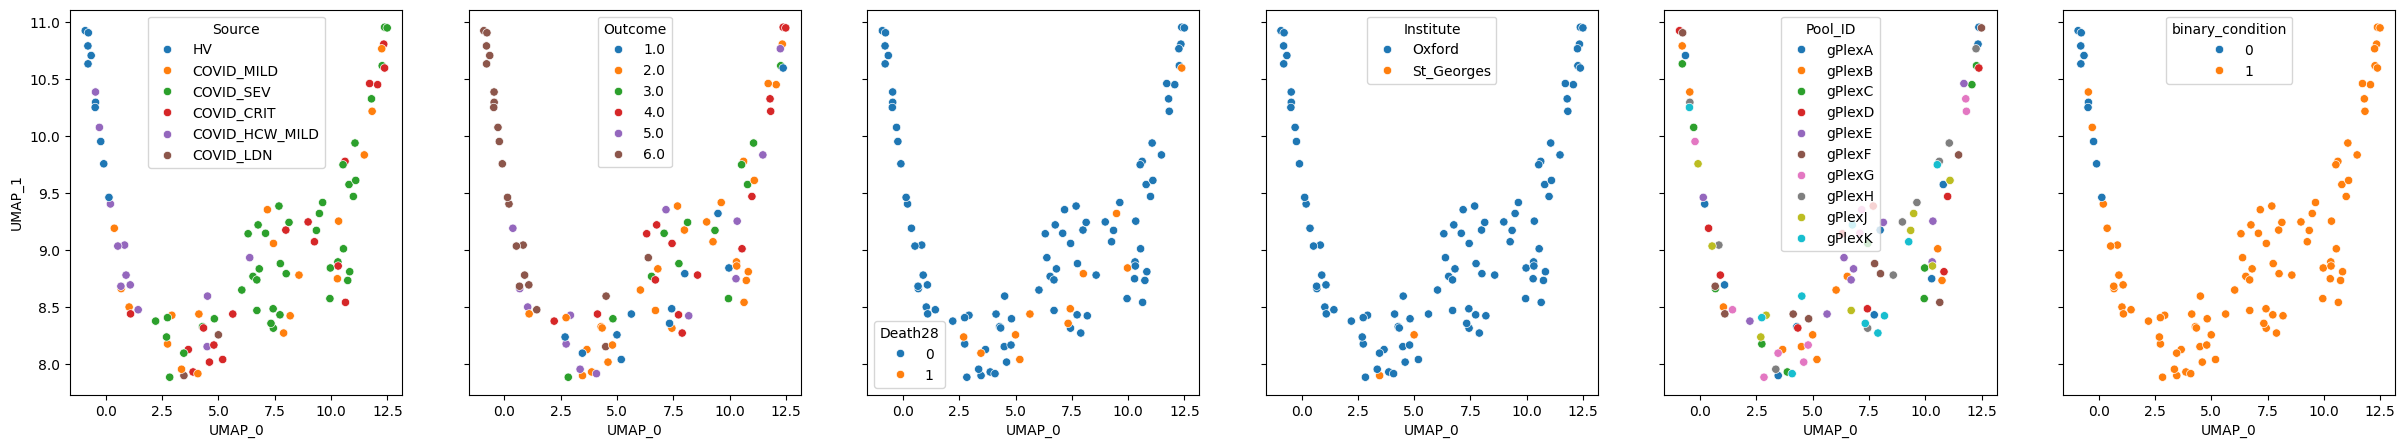

In [14]:
pascient.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

## Binary prediction

Fine-tune a linear probe on top of the learned representations and predict.

In [15]:
pascient.fine_tune("binary_condition", tasks="classification")

In [16]:
pascient_prediction = pascient.predict("binary_condition")
pascient_prediction

,prob_0,prob_1,binary_condition_pred
S00109-Ja001E-PBCa,0.074583,0.925417,1
S00112-Ja003E-PBCa,0.010154,0.989846,1
S00005-Ja005E-PBCa,0.016329,0.983671,1
S00061-Ja003E-PBCa,0.000360,0.999640,1
S00056-Ja003E-PBCa,0.004467,0.995533,1
...,...,...,...
S00076-Ja001E-PBCa,0.090108,0.909892,1
S00072-Ja001E-PBCa,0.228547,0.771453,1
S00065-Ja003E-PBCa,0.012358,0.987642,1
S00048-Ja003E-PBCa,0.025928,0.974072,1


In [17]:
y_true = metadata.loc[pascient_prediction.index, "binary_condition"]
print(classification_report(y_true, pascient_prediction["binary_condition_pred"]))

              precision    recall  f1-score   support

           0       0.62      1.00      0.77        10
           1       1.00      0.93      0.97        91

    accuracy                           0.94       101
   macro avg       0.81      0.97      0.87       101
weighted avg       0.96      0.94      0.95       101



## Multiclass prediction

We can also fine-tune for the multiclass `Source` label.

In [18]:
metadata["Source"].value_counts()

Source
COVID_SEV         41
COVID_MILD        18
COVID_CRIT        18
COVID_HCW_MILD    12
HV                10
COVID_LDN          2
Name: count, dtype: int64

In [19]:
pascient.fine_tune("Source", tasks="classification")

In [20]:
pascient_source_prediction = pascient.predict("Source")
pascient_source_prediction

,prob_COVID_CRIT,prob_COVID_HCW_MILD,prob_COVID_LDN,prob_COVID_MILD,prob_COVID_SEV,prob_HV,Source_pred
S00109-Ja001E-PBCa,0.179247,0.170079,0.206048,0.222314,0.199228,0.023084,COVID_MILD
S00112-Ja003E-PBCa,0.271662,0.050523,0.157276,0.239380,0.279023,0.002136,COVID_SEV
S00005-Ja005E-PBCa,0.286546,0.067012,0.185745,0.202227,0.254738,0.003733,COVID_CRIT
S00061-Ja003E-PBCa,0.345795,0.005524,0.048257,0.200244,0.400149,0.000032,COVID_SEV
S00056-Ja003E-PBCa,0.319201,0.030711,0.133414,0.211089,0.304810,0.000775,COVID_CRIT
...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,0.183454,0.182807,0.196636,0.222766,0.185908,0.028429,COVID_MILD
S00072-Ja001E-PBCa,0.125679,0.265112,0.182357,0.198260,0.140448,0.088143,COVID_HCW_MILD
S00065-Ja003E-PBCa,0.299180,0.057270,0.141342,0.223965,0.275562,0.002681,COVID_CRIT
S00048-Ja003E-PBCa,0.269094,0.086780,0.166548,0.218218,0.252808,0.006552,COVID_CRIT


In [21]:
source_true = metadata.loc[pascient_source_prediction.index, "Source"]
print(classification_report(source_true, pascient_source_prediction["Source_pred"]))

                precision    recall  f1-score   support

    COVID_CRIT       0.36      0.50      0.42        18
COVID_HCW_MILD       0.38      0.50      0.43        12
     COVID_LDN       0.40      1.00      0.57         2
    COVID_MILD       0.31      0.28      0.29        18
     COVID_SEV       0.65      0.41      0.51        41
            HV       0.77      1.00      0.87        10

      accuracy                           0.49       101
     macro avg       0.48      0.62      0.51       101
  weighted avg       0.51      0.49      0.48       101



### Cell importance: Integrated Gradients vs. cosine similarity

PaSCient supports two methods for computing cell importance:

1. **Integrated Gradients (IG)** — the approach from the PaSCient paper ([De Brouwer et al., 2024](https://arxiv.org/abs/2404.14413)). It uses [captum](https://captum.ai/) to attribute the model's prediction to each cell by accumulating gradients along a path from a zero baseline. The per-cell score is the L2 norm of the per-gene IG attribution vector. Requires the `captum` package.

2. **Cosine similarity** — a lightweight proxy that measures the cosine similarity between each cell's embedding and the patient-level embedding. No extra dependencies needed.

Let's compute both and compare.

In [22]:
# Integrated Gradients (default when captum is installed)
ig_scores = pascient._cell_importance_ig(target=0)

# Cosine similarity fallback
cosine_scores = pascient._cell_importance_cosine()

print(f"IG scores: min={ig_scores.min():.4f}, max={ig_scores.max():.4f}, mean={ig_scores.mean():.4f}")
print(f"Cosine scores: min={cosine_scores.min():.4f}, max={cosine_scores.max():.4f}, mean={cosine_scores.mean():.4f}")

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:2098: UserWarning: Using data from adata.layers['X_raw_counts']
  cell_data = self._get_data()[cell_mask]


IG scores: min=0.0000, max=0.0023, mean=0.0000
Cosine scores: min=0.0000, max=0.2243, mean=0.0778


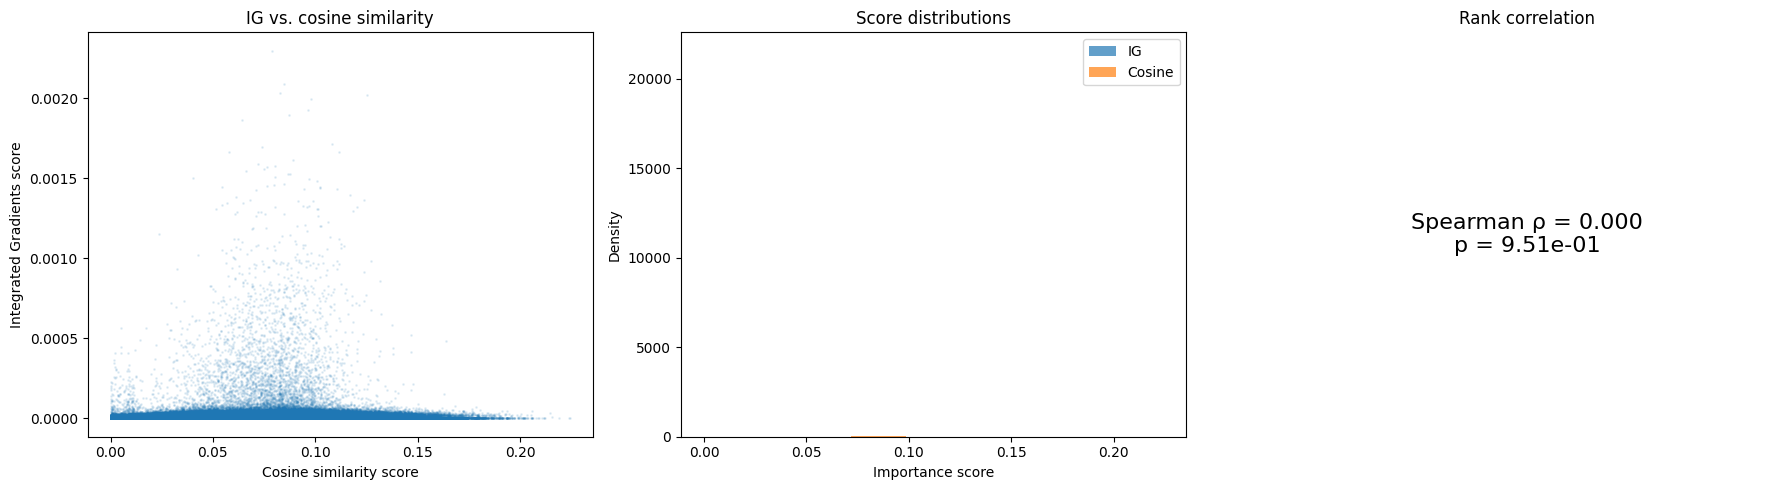

In [23]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: IG vs cosine
axes[0].scatter(cosine_scores, ig_scores, alpha=0.1, s=1)
axes[0].set_xlabel("Cosine similarity score")
axes[0].set_ylabel("Integrated Gradients score")
axes[0].set_title("IG vs. cosine similarity")

# Distribution comparison
axes[1].hist(ig_scores, bins=50, alpha=0.7, label="IG", density=True)
axes[1].hist(cosine_scores, bins=50, alpha=0.7, label="Cosine", density=True)
axes[1].set_xlabel("Importance score")
axes[1].set_ylabel("Density")
axes[1].set_title("Score distributions")
axes[1].legend()

# Rank correlation
from scipy.stats import spearmanr
rho, pval = spearmanr(ig_scores, cosine_scores)
axes[2].text(0.5, 0.5, f"Spearman ρ = {rho:.3f}\np = {pval:.2e}",
             ha="center", va="center", fontsize=16, transform=axes[2].transAxes)
axes[2].set_title("Rank correlation")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Cell importance by disease severity and cell type

Visualize the distribution of cell importance scores. Since most scores are near zero with a long tail of important cells, we use strip plots with log-scaled y-axis for better visibility.

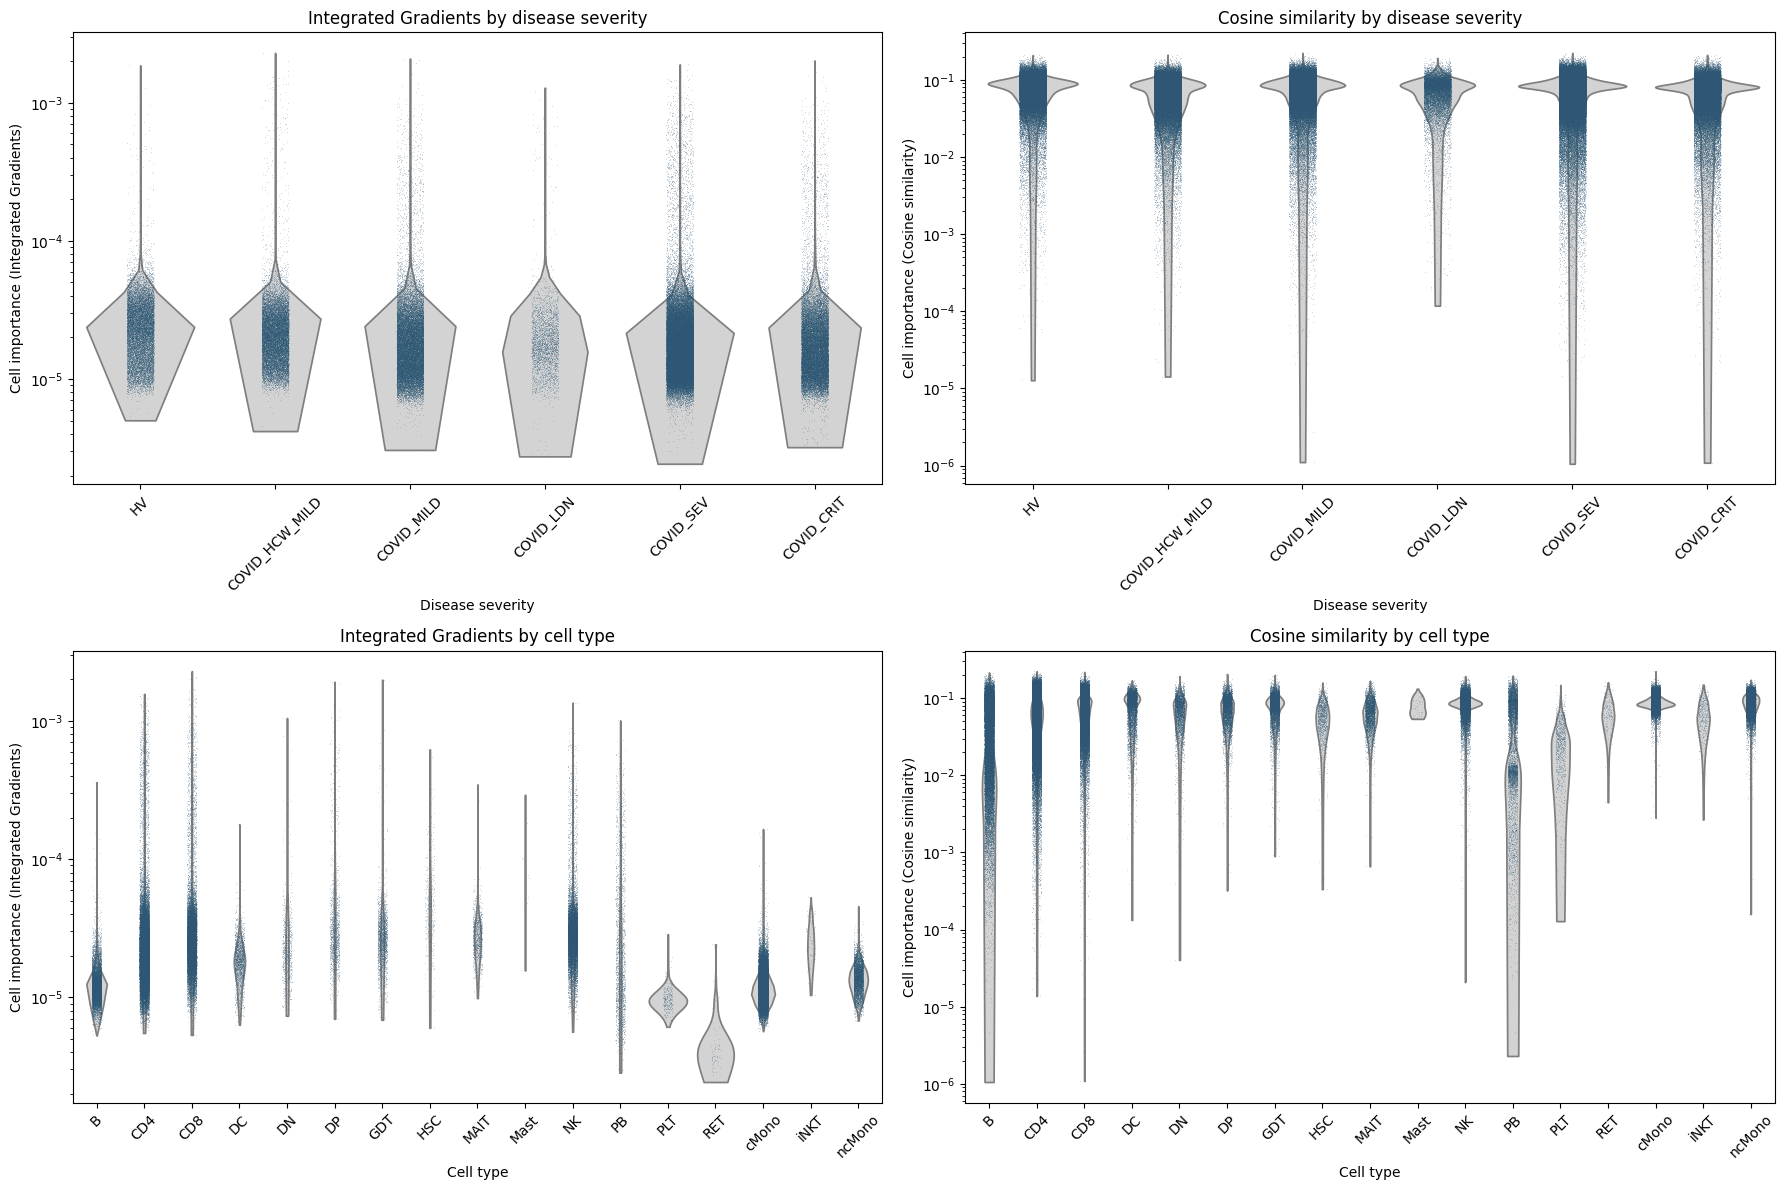

In [24]:
# Build dataframe with both importance methods and metadata
cell_imp_df = pd.DataFrame({
    "ig_importance": ig_scores,
    "cosine_importance": cosine_scores,
    "Source": adata.obs["Source"].values,
    "cell_type": adata.obs[cell_type_key].values,
}, index=adata.obs_names)

severity_order = ["HV", "COVID_HCW_MILD", "COVID_MILD", "COVID_LDN", "COVID_SEV", "COVID_CRIT"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for col_idx, (method, col) in enumerate([("Integrated Gradients", "ig_importance"), ("Cosine similarity", "cosine_importance")]):
    # Filter to nonzero for log-scale strip plot
    nonzero = cell_imp_df[cell_imp_df[col] > 0]

    # By disease severity
    ax = axes[0, col_idx]
    sns.violinplot(data=nonzero, x="Source", y=col, order=severity_order,
                   cut=0, inner=None, color="lightgrey", ax=ax)
    sns.stripplot(data=nonzero, x="Source", y=col, order=severity_order,
                  size=0.5, alpha=0.3, jitter=True, ax=ax)
    ax.set_yscale("log")
    ax.set_xlabel("Disease severity")
    ax.set_ylabel(f"Cell importance ({method})")
    ax.set_title(f"{method} by disease severity")
    ax.tick_params(axis="x", rotation=45)

    # By cell type
    ax = axes[1, col_idx]
    sns.violinplot(data=nonzero, x="cell_type", y=col,
                   cut=0, inner=None, color="lightgrey", ax=ax)
    sns.stripplot(data=nonzero, x="cell_type", y=col,
                  size=0.5, alpha=0.3, jitter=True, ax=ax)
    ax.set_yscale("log")
    ax.set_xlabel("Cell type")
    ax.set_ylabel(f"Cell importance ({method})")
    ax.set_title(f"{method} by cell type")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Summary statistics

Descriptive statistics of cell importance scores grouped by disease severity and cell type, for both the IG and cosine methods.

In [25]:
print("=== Integrated Gradients importance by disease severity ===")
cell_imp_df.groupby("Source")["ig_importance"].describe().loc[severity_order].round(6)

=== Integrated Gradients importance by disease severity ===


/localscratch/vladimir.shitov/ipykernel_2436341/1305302691.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_imp_df.groupby("Source")["ig_importance"].describe().loc[severity_order].round(6)


,count,mean,std,min,25%,50%,75%,max
Source,,,,,,,,
HV,87204.0,0.000005,0.000018,0.0,0.0,0.0,0.000000,0.001866
COVID_HCW_MILD,84359.0,0.000006,0.000033,0.0,0.0,0.0,0.000000,0.002297
COVID_MILD,107376.0,0.000007,0.000032,0.0,0.0,0.0,0.000007,0.002091
COVID_LDN,14832.0,0.000005,0.000032,0.0,0.0,0.0,0.000000,0.001288
COVID_SEV,230343.0,0.000007,0.000035,0.0,0.0,0.0,0.000009,0.001897
COVID_CRIT,87620.0,0.000008,0.000035,0.0,0.0,0.0,0.000011,0.002022


In [26]:
print("=== Cosine similarity importance by disease severity ===")
cell_imp_df.groupby("Source")["cosine_importance"].describe().loc[severity_order].round(6)

=== Cosine similarity importance by disease severity ===


/localscratch/vladimir.shitov/ipykernel_2436341/2970078465.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_imp_df.groupby("Source")["cosine_importance"].describe().loc[severity_order].round(6)


,count,mean,std,min,25%,50%,75%,max
Source,,,,,,,,
HV,87204.0,0.080907,0.027906,0.000013,0.064481,0.084980,0.098385,0.210484
COVID_HCW_MILD,84359.0,0.073211,0.029687,0.000000,0.052052,0.077935,0.093762,0.212284
COVID_MILD,107376.0,0.079478,0.029399,0.000001,0.062235,0.083439,0.098063,0.223739
COVID_LDN,14832.0,0.075491,0.029630,0.000118,0.055754,0.078857,0.094651,0.192458
COVID_SEV,230343.0,0.079814,0.027696,0.000001,0.066943,0.082907,0.095442,0.224258
COVID_CRIT,87620.0,0.072472,0.028472,0.000000,0.054877,0.077431,0.089340,0.211567


In [27]:
print("=== Integrated Gradients importance by cell type ===")
cell_imp_df.groupby("cell_type")["ig_importance"].describe().round(6)

=== Integrated Gradients importance by cell type ===


/localscratch/vladimir.shitov/ipykernel_2436341/1516414347.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_imp_df.groupby("cell_type")["ig_importance"].describe().round(6)


,count,mean,std,min,25%,50%,75%,max
cell_type,,,,,,,,
B,37103.0,0.000003,0.000007,0.0,0.0,0.0,0.000008,0.000362
CD4,218353.0,0.000007,0.000034,0.0,0.0,0.0,0.000000,0.001574
CD8,87562.0,0.000010,0.000052,0.0,0.0,0.0,0.000000,0.002297
DC,7287.0,0.000005,0.000009,0.0,0.0,0.0,0.000000,0.000179
DN,3426.0,0.000007,0.000036,0.0,0.0,0.0,0.000000,0.001052
DP,5354.0,0.000017,0.000084,0.0,0.0,0.0,0.000000,0.001925
GDT,7935.0,0.000008,0.000032,0.0,0.0,0.0,0.000000,0.001994
HSC,1124.0,0.000019,0.000047,0.0,0.0,0.0,0.000024,0.000624
MAIT,3977.0,0.000006,0.000014,0.0,0.0,0.0,0.000000,0.000347


In [28]:
print("=== Cosine similarity importance by cell type ===")
cell_imp_df.groupby("cell_type")["cosine_importance"].describe().round(6)

=== Cosine similarity importance by cell type ===


/localscratch/vladimir.shitov/ipykernel_2436341/4008351109.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_imp_df.groupby("cell_type")["cosine_importance"].describe().round(6)


,count,mean,std,min,25%,50%,75%,max
cell_type,,,,,,,,
B,37103.0,0.054749,0.040121,0.000001,0.016049,0.052239,0.087299,0.215563
CD4,218353.0,0.071145,0.031322,0.000000,0.048590,0.069404,0.091774,0.223739
CD8,87562.0,0.077554,0.029029,0.000000,0.057204,0.079699,0.097576,0.218718
DC,7287.0,0.085168,0.030304,0.000133,0.066599,0.091549,0.106743,0.170617
DN,3426.0,0.072372,0.029619,0.000040,0.051423,0.073902,0.092253,0.193500
DP,5354.0,0.075758,0.028253,0.000322,0.055928,0.075717,0.094477,0.205932
GDT,7935.0,0.082807,0.026360,0.000896,0.067461,0.085196,0.099123,0.200246
HSC,1124.0,0.062138,0.026769,0.000335,0.042537,0.060649,0.080189,0.159348
MAIT,3977.0,0.068108,0.025823,0.000661,0.049443,0.066722,0.085131,0.168240


## Recompute distances and visualize after fine-tuning

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


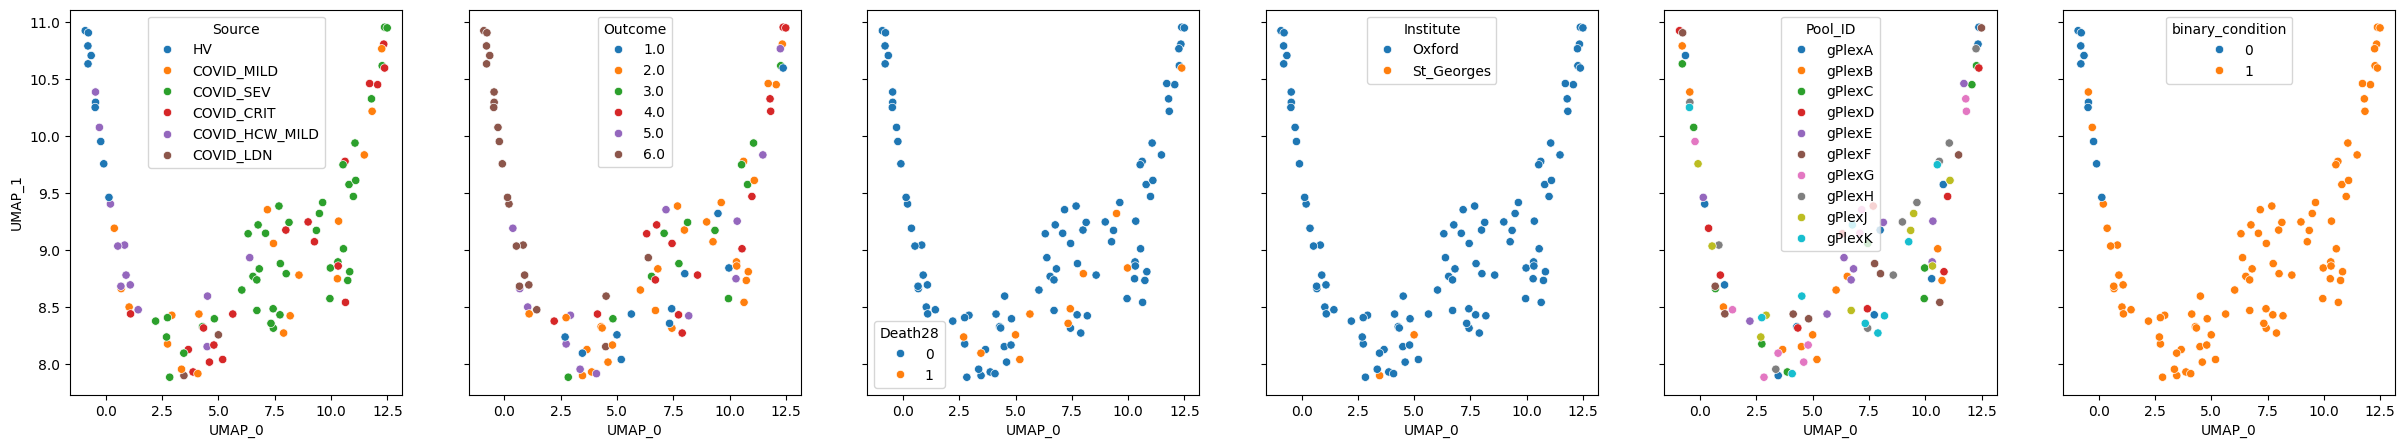

In [29]:
pascient.calculate_distance_matrix()
pascient.embed("UMAP")
pascient.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

In this tutorial you learned how to train PaSCient from scratch, extract sample representations, evaluate them, make binary and multiclass predictions, and compute importance scores with `patpy`.